In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import sys
import os
import joblib

sys.path.append(os.path.abspath(".."))
os.makedirs("../artifacts", exist_ok=True)

In [2]:
from src.preprocessing import clean_data

df = pd.read_csv("../data/ai4i2020.csv")
print("Columns in data : ",df.columns)
df = clean_data(df)
x = df.drop('Machine failure',axis='columns')
feature_columns = x.columns.tolist()

joblib.dump(feature_columns, "../artifacts/feature_columns.pkl")

HI from preprocessing.py
Columns in data :  Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')


['../artifacts/feature_columns.pkl']

In [3]:
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay as cmd

x = df.drop('Machine failure',axis='columns')
y = df['Machine failure']
xtrain,xtest,ytrain,ytest = tts(x,y,stratify=y,test_size=0.2,random_state=42)

Accuracy score by using XGB classifier =  0.9885


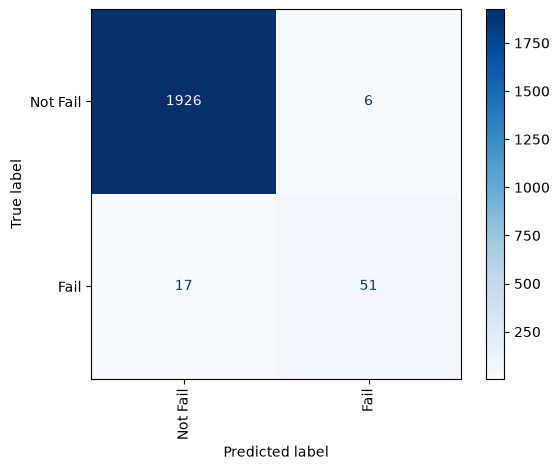

In [4]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)
model.fit(xtrain,ytrain)
ypred = model.predict(xtest)
print("Accuracy score by using XGB classifier = ",accuracy_score(ytest,ypred))
cmd.from_estimator(model,xtest,ytest,display_labels=['Not Fail','Fail'],cmap='Blues',xticks_rotation='vertical')
plt.show()

In [5]:
joblib.dump(model,"../artifacts/model.pkl")

['../artifacts/model.pkl']

In [6]:
import joblib

model = joblib.load("../artifacts/model.pkl")

print(model.score(xtest, ytest))

0.9885


In [7]:
from sklearn.metrics import classification_report

y_pred = model.predict(xtest)

classification_report = classification_report(ytest, y_pred)
joblib.dump(classification_report,"../artifacts/classification_report")

['../artifacts/classification_report']

In [8]:
print(classification_report)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.75      0.82        68

    accuracy                           0.99      2000
   macro avg       0.94      0.87      0.91      2000
weighted avg       0.99      0.99      0.99      2000



In [9]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(xtest)[:,1]

auc = roc_auc_score(ytest, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9699716843259043


In [10]:
import joblib

cols = joblib.load("../artifacts/feature_columns.pkl")
print(cols)

['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'L', 'M']
